<a href="https://colab.research.google.com/github/data-shkim/book-self-study-ml-dl/blob/main/%ED%98%BC%EC%9E%90%EA%B3%B5%EB%B6%80%ED%95%98%EB%8A%94%EB%A8%B8%EC%8B%A0%EB%9F%AC%EB%8B%9D%2B%EB%94%A5%EB%9F%AC%EB%8B%9D_04.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import pandas as pd

fish = pd.read_csv('https://bit.ly/fish_csv_data')
fish.head()
print(pd.unique(fish['Species']))

['Bream' 'Roach' 'Whitefish' 'Parkki' 'Perch' 'Pike' 'Smelt']


In [ ]:
fish_input = fish[['Weight', 'Length', 'Diagonal', 'Height', 'Width']]
fish_input.head()

,Weight,Length,Diagonal,Height,Width
0,242.0,25.4,30.0,11.5200,4.0200
1,290.0,26.3,31.2,12.4800,4.3056
2,340.0,26.5,31.1,12.3778,4.6961
3,363.0,29.0,33.5,12.7300,4.4555
4,430.0,29.0,34.0,12.4440,5.1340


In [ ]:
fish_target = fish['Species']

In [ ]:
from sklearn.model_selection import train_test_split
train_input, test_input, train_target, test_target = train_test_split(fish_input, fish_target, random_state=42)

In [ ]:
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
ss.fit(train_input)
train_scaled = ss.transform(train_input)
test_scaled = ss.transform(test_input)

In [ ]:
from sklearn.neighbors import KNeighborsClassifier
kn = KNeighborsClassifier(n_neighbors=3)
kn.fit(train_scaled, train_target)
print(kn.score(train_scaled, train_target))
print(kn.score(test_scaled, test_target))

0.8907563025210085
0.85


In [ ]:
import numpy as np
proba = kn.predict_proba(test_scaled[:5])
np.vstack([kn.classes_, np.round(proba, decimals=4)])

array([['Bream', 'Parkki', 'Perch', 'Pike', 'Roach', 'Smelt',
        'Whitefish'],
       [0.0, 0.0, 1.0, 0.0, 0.0, 0.0, 0.0],
       [0.0, 0.0, 0.0, 0.0, 0.0, 1.0, 0.0],
       [0.0, 0.0, 0.0, 1.0, 0.0, 0.0, 0.0],
       [0.0, 0.0, 0.6667, 0.0, 0.3333, 0.0, 0.0],
       [0.0, 0.0, 0.6667, 0.0, 0.3333, 0.0, 0.0]], dtype=object)

In [ ]:
distances, indexes = kn.kneighbors(test_scaled[3:4])
train_target.iloc[indexes[0]]

,Species
52,Roach
106,Perch
103,Perch


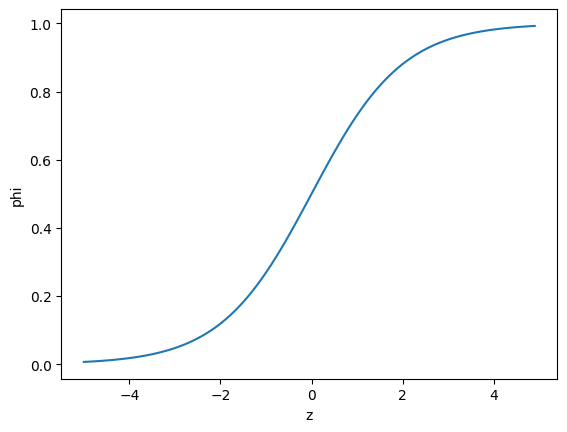

In [ ]:
# 로지스틱 회귀: 선형 방정식 학습
# 각 클래스일 '확률'을 구해야 하므로 0~1 사이 값이 되어야 함 -> 시그모이드 함수 활용
# sigmoid(z) = 1 / (1 + e^(-z))

import numpy as np
import matplotlib.pyplot as plt
z = np.arange(-5, 5, 0.1)
phi = 1 / (1+np.exp(-z))
plt.plot(z, phi)
plt.xlabel('z')
plt.ylabel('phi')
plt.show()

In [ ]:
# 불리언 인덱싱
char_arr = np.array(['A','B','C','D','E'])
print(char_arr[[True, False, True, False, False]])

bream_smelt_indexes = (train_target == 'Bream') | (train_target == 'Smelt')
train_bream_smelt = train_scaled[bream_smelt_indexes]
target_bream_smelt = train_target[bream_smelt_indexes]

['A' 'C']


In [ ]:
from sklearn.linear_model import LogisticRegression
lr = LogisticRegression()
lr.fit(train_bream_smelt, target_bream_smelt)

LogisticRegression()

In [ ]:
print(lr.predict(train_bream_smelt[:5]))
print(lr.predict_proba(train_bream_smelt[:5]))
print(lr.classes_)

np.vstack([lr.classes_, lr.predict_proba(train_bream_smelt[:5])])

['Bream' 'Smelt' 'Bream' 'Bream' 'Bream']
[[0.99760007 0.00239993]
 [0.02737325 0.97262675]
 [0.99486386 0.00513614]
 [0.98585047 0.01414953]
 [0.99767419 0.00232581]]
['Bream' 'Smelt']


array([['Bream', 'Smelt'],
       [0.9976000716505207, 0.0023999283494792883],
       [0.027373246361962256, 0.9726267536380377],
       [0.9948638644793271, 0.005136135520672965],
       [0.9858504680159297, 0.014149531984070287],
       [0.9976741864891663, 0.002325813510833753]], dtype=object)

In [ ]:
print(lr.coef_, lr.intercept_)
decisions = lr.decision_function(train_bream_smelt[:5]) # lr.coef_, lr.intercept_ 를 대입한 방정식 결과
print(decisions)

[[-0.40451732 -0.57582787 -0.66248158 -1.01329614 -0.73123131]] [-2.16172774]
[-6.02991358  3.57043428 -5.26630496 -4.24382314 -6.06135688]


In [ ]:
from scipy.special import expit
print(expit(decisions)) # 시그모이드 함수로 방정식 결과를 변환

[0.00239993 0.97262675 0.00513614 0.01414953 0.00232581]


In [ ]:
lr = LogisticRegression(C=20, max_iter=1000)  # 릿지 회귀처럼 계수 제곱을 규제(L2 규제) C 로 제어하고 규제 완화 위해 기본값 1 -> 20
lr.fit(train_scaled, train_target)
print(lr.score(train_scaled, train_target))
print(lr.score(test_scaled, test_target))

print(lr.predict(test_scaled[:5]))
proba = lr.predict_proba(test_scaled[:5])
print(np.round(proba, decimals=3))

np.vstack([lr.classes_, np.round(proba, decimals=3)])

0.9327731092436975
0.925
['Perch' 'Smelt' 'Pike' 'Roach' 'Perch']
[[0.    0.014 0.842 0.    0.135 0.007 0.003]
 [0.    0.003 0.044 0.    0.007 0.946 0.   ]
 [0.    0.    0.034 0.934 0.015 0.016 0.   ]
 [0.011 0.034 0.305 0.006 0.567 0.    0.076]
 [0.    0.    0.904 0.002 0.089 0.002 0.001]]


array([['Bream', 'Parkki', 'Perch', 'Pike', 'Roach', 'Smelt',
        'Whitefish'],
       [0.0, 0.014, 0.842, 0.0, 0.135, 0.007, 0.003],
       [0.0, 0.003, 0.044, 0.0, 0.007, 0.946, 0.0],
       [0.0, 0.0, 0.034, 0.934, 0.015, 0.016, 0.0],
       [0.011, 0.034, 0.305, 0.006, 0.567, 0.0, 0.076],
       [0.0, 0.0, 0.904, 0.002, 0.089, 0.002, 0.001]], dtype=object)

In [ ]:
print(lr.coef_.shape, lr.intercept_.shape)

# 소프트맥스 함수: 여러 개의 선형 방정식의 출력값을 0~1 사이의 확률로 압축하고 전체 확률이 1이 되도록 만듦 (시그모이드는 하나의 선형 방정식 출력 값을 0~1 사이)
# 최댓값에 높은 확률을 할당하지만 다른 값에도 작은 확률 부여

(7, 5) (7,)


In [ ]:
decision = lr.decision_function(test_scaled[:5])
print(np.round(decision, decimals=2))

[[ -6.51   1.04   5.17  -2.76   3.34   0.35  -0.63]
 [-10.88   1.94   4.78  -2.42   2.99   7.84  -4.25]
 [ -4.34  -6.24   3.17   6.48   2.36   2.43  -3.87]
 [ -0.69   0.45   2.64  -1.21   3.26  -5.7    1.26]
 [ -6.4   -1.99   5.82  -0.13   3.5   -0.09  -0.7 ]]


In [ ]:
from scipy.special import softmax
proba = softmax(decision, axis=1)
print(np.round(proba, decimals=3))
proba = softmax(decision)
print(np.round(proba, decimals=3))

[[0.    0.014 0.842 0.    0.135 0.007 0.003]
 [0.    0.003 0.044 0.    0.007 0.946 0.   ]
 [0.    0.    0.034 0.934 0.015 0.016 0.   ]
 [0.011 0.034 0.305 0.006 0.567 0.    0.076]
 [0.    0.    0.904 0.002 0.089 0.002 0.001]]
[[0.    0.001 0.044 0.    0.007 0.    0.   ]
 [0.    0.002 0.03  0.    0.005 0.634 0.   ]
 [0.    0.    0.006 0.163 0.003 0.003 0.   ]
 [0.    0.    0.004 0.    0.006 0.    0.001]
 [0.    0.    0.084 0.    0.008 0.    0.   ]]


In [ ]:
'''
확률적 경사 하강법(Stochastic Gradient Descent)
- 샘플을 1개씩 -> 확률적 경사 하강법
- 여러개씩 -> 미니배치 경사 하강법
- 전체 -> 배치 경사 하강법
=> 훈련 데이터가 모두 준비되어 있지 않아도 매번 업데이트되어도 학습을 계속 이어나갈 수 있음

손실함수(loss function)
- 샘플 하나에 대한 손실
- 경사하강법을 사용하려면 손실함수는 미분 가능해야 함

비용함수(cost function)
- 훈련 세트에 있는 모든 샘플에 대한 손실 함수의 합
'''

In [ ]:
import pandas as pd
fish = pd.read_csv('https://bit.ly/fish_csv_data')

In [ ]:
fish_input = fish[['Weight', 'Length', 'Diagonal', 'Height', 'Width']]
fish_target = fish['Species']

In [ ]:
from sklearn.model_selection import train_test_split

train_input, test_input, train_target, test_target = train_test_split(fish_input, fish_target, random_state=42)

In [ ]:
from sklearn.preprocessing import StandardScaler
ss = StandardScaler()
ss.fit(train_input)
train_scaled = ss.transform(train_input)
test_scaled = ss.transform(test_input)

In [ ]:
from sklearn.linear_model import SGDClassifier

sc = SGDClassifier(loss='log_loss', max_iter=10, random_state=42)
sc.fit(train_scaled, train_target)
print(sc.score(train_scaled, train_target))
print(sc.score(test_scaled, test_target))

sc.partial_fit(train_scaled, train_target)  # 호출할 때마다 1에포크씩 이어서 훈련
print(sc.score(train_scaled, train_target))
print(sc.score(test_scaled, test_target))

0.773109243697479
0.775
0.7983193277310925
0.775


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_stochastic_gradient.py:738: ConvergenceWarning: Maximum number of iteration reached before convergence. Consider increasing max_iter to improve the fit.
  warnings.warn(


In [48]:
import numpy as np
sc = SGDClassifier(loss='log_loss', random_state=42)
train_score = []
test_score = []
classes = np.unique(train_target)

for _ in range(0, 300):
  sc.partial_fit(train_scaled, train_target, classes=classes)
  train_score.append(sc.score(train_scaled, train_target))
  test_score.append(sc.score(test_scaled, test_target))

print(train_score)
print(test_score)

[0.5294117647058824, 0.6218487394957983, 0.6386554621848739, 0.7142857142857143, 0.7142857142857143, 0.7394957983193278, 0.7058823529411765, 0.7226890756302521, 0.7563025210084033, 0.8067226890756303, 0.8151260504201681, 0.8487394957983193, 0.8487394957983193, 0.865546218487395, 0.8739495798319328, 0.8571428571428571, 0.8571428571428571, 0.8739495798319328, 0.8739495798319328, 0.8739495798319328, 0.8823529411764706, 0.865546218487395, 0.8739495798319328, 0.8739495798319328, 0.8907563025210085, 0.8907563025210085, 0.8739495798319328, 0.8907563025210085, 0.8991596638655462, 0.8991596638655462, 0.8991596638655462, 0.8907563025210085, 0.8907563025210085, 0.8823529411764706, 0.907563025210084, 0.8991596638655462, 0.9243697478991597, 0.907563025210084, 0.9243697478991597, 0.9159663865546218, 0.9159663865546218, 0.9243697478991597, 0.9327731092436975, 0.9243697478991597, 0.9327731092436975, 0.9243697478991597, 0.9327731092436975, 0.9327731092436975, 0.9327731092436975, 0.9327731092436975, 0.9

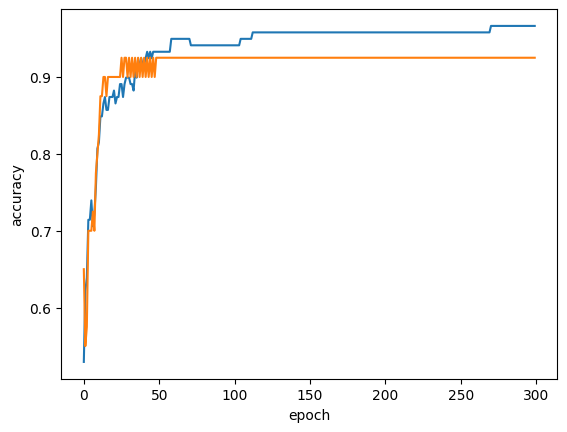

In [51]:
import matplotlib.pyplot as plt
plt.plot(train_score)
plt.plot(test_score)
plt.xlabel('epoch')
plt.ylabel('accuracy')
plt.show()

In [53]:
sc = SGDClassifier(loss='log_loss', max_iter=100, tol=None, random_state=42)
sc.fit(train_scaled, train_target)
print(sc.score(train_scaled, train_target))
print(sc.score(test_scaled, test_target))

0.957983193277311
0.925


In [54]:
sc = SGDClassifier(loss='hinge', max_iter=100, tol=None, random_state=42) # hinge 손실
sc.fit(train_scaled, train_target)
print(sc.score(train_scaled, train_target))
print(sc.score(test_scaled, test_target))

0.9495798319327731
0.925
